### Necessary Imports

In [1]:
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
import os
import pathlib
import polars as pl

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

#### Now let's open the allgaiadata.parq files from Zenodo to make our HR Diagram. 

#### This file is quite large (> 6GB), which means as it is being opened the memory request on your device may be substantial (>30GB requested). On my machine (8 core 16GB of memory), this file takes more than 6.5 minutes to open. 

(So go take a walk while you wait for this to open up)

In [3]:
gaiaids = pl.read_parquet('allgaiadata.parq').to_pandas()
gaiaids['bp-rp'] = gaiaids['phot_bp_mean_mag'] - gaiaids['phot_rp_mean_mag']
gaiaids['abs_g_mag'] = gaiaids['phot_g_mean_mag'] - 5*np.log10(1000/gaiaids['parallax']) + 5
gaiaids.drop_duplicates(inplace=True)

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


#### Now we'll plot it

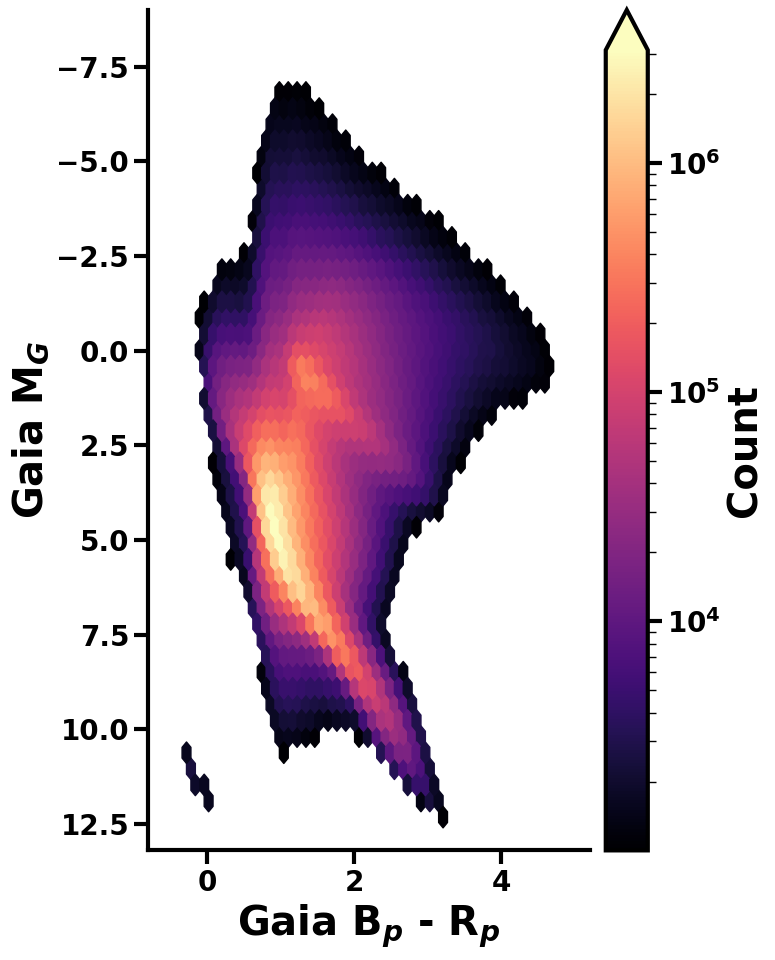

In [4]:
fig, axs = plt.subplots(1, 1, figsize=(8, 10))
axs.set(xlim=(-0.8, 5.2), ylim=(13.2, -9), xlabel='Gaia B$_p$ - R$_p$', ylabel='Gaia M$_G$')
im1 = axs.hexbin('bp-rp', 'abs_g_mag', data=gaiaids, mincnt=1000, bins='log', cmap='magma', rasterized=True)
fig.colorbar(im1, pad=0.03, label='Count', extend='max')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
fig.tight_layout()

#plt.savefig('gaia_hr.pdf', dpi=300)